### This notebook compute "VSS4. Human Development Index " indicator for the 27 basins of IKI Project

Spanish: Índice de Desarrollo Humano

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite database. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, Indice de Desarrollo Humano (IDH) 2019 de Programa de las Naciones Unidas para el Desarrollo (PNUD, 2019): https://www.undp.org/es/peru/publicaciones/el-reto-de-la-igualdad

**Outputs:** 
 
**Assumptions:** Assume ID based on majority district associated with each COMID. 
 
**Future work:** Normalize. Could look into using a proportional method as opposed to a majority district method. Could look into calculating the IDH from scratch for each COMID but this would require further data. 
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 404 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [3]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in excel  (save xls as xlsx as needed before reading in)
InDH= pd.read_excel(f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/VSS4_IDH-2019.xlsx', sheet_name= 'Distrital')

#top_row_name= 'Temas de la capacitación'

In [4]:
#FORMATTING THE DATAFRAME

#make the second row the header
InDH.columns = InDH.iloc[1]
InDH = InDH[2:].reset_index(drop=True)

#remove empty rows N
InDH = InDH.dropna(axis=0, how='all')  # Drop rows that are completely NaN
#remove empty columns
InDH = InDH.dropna(axis=1, how='all')  # Drop columns that are completely NaN

#keep UBIGEO and Índice de Desarrollo Humano columns only
InDH = InDH[['UBIGEO', 'Índice de Desarrollo Humano']].copy()

#Rename UBIGEO to District_ID for merging
InDH = InDH.rename(columns={'UBIGEO': 'District_ID'})

#Remove any rows where the value is not a number 
InDH = InDH[pd.to_numeric(InDH['Índice de Desarrollo Humano'], errors='coerce').notnull()]

In [5]:
#MERGE DATAFRAMES BASED ON MAJORITY DISTRICT ID PER COMID

# Convert both columns to strings to be able to join them together
subbasins_gdf['IDDIST'] = subbasins_gdf['IDDIST'].astype(str)
InDH['District_ID'] = InDH['District_ID'].astype(str)

#Rename Índice de Desarrollo Humano column to IDH
InDH = InDH.rename(columns={'Índice de Desarrollo Humano': 'IDH'})

#Round to 2 decimal places 
InDH['IDH'] = InDH['IDH'].astype(float).round(2)

#merge Total_Dist column back to subbasins_gdf based on IDDIST and District_ID
subbasins_gdf = subbasins_gdf.merge(InDH[['District_ID', 'IDH']], left_on='IDDIST', right_on='District_ID', how='left')

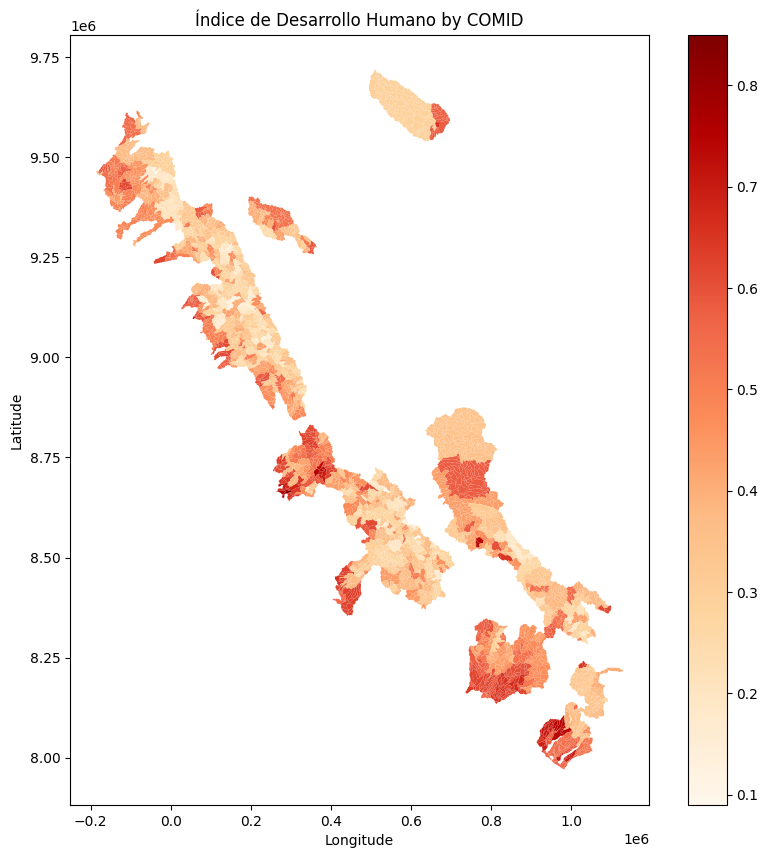

In [6]:
#PLOT THE RESULTS

subbasins_gdf.plot(column='IDH', cmap='OrRd', legend=True, figsize=(10, 10))
plt.title('Índice de Desarrollo Humano by COMID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

SQLITE INSERT 

In [7]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and IDH
value_column= 'IDH'

In [8]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [9]:
rows_to_insert

[(1, 404, 311153600, 0.29),
 (1, 404, 310832400, 0.24),
 (1, 404, 310825700, 0.52),
 (1, 404, 310282400, 0.66),
 (1, 404, 308754600, 0.63),
 (1, 404, 307736500, 0.61),
 (1, 404, 307078200, 0.15),
 (1, 404, 307183500, 0.45),
 (1, 404, 306538400, 0.53),
 (1, 404, 306599700, 0.62),
 (1, 404, 306319300, 0.47),
 (1, 404, 306030000, 0.47),
 (1, 404, 305746400, 0.39),
 (1, 404, 311953100, 0.7),
 (1, 404, 304273900, 0.29),
 (1, 404, 304281100, 0.29),
 (1, 404, 304281200, 0.29),
 (1, 404, 304379300, 0.29),
 (1, 404, 304274000, 0.29),
 (1, 404, 304313700, 0.29),
 (1, 404, 304306400, 0.29),
 (1, 404, 304327700, 0.29),
 (1, 404, 304313800, 0.29),
 (1, 404, 304306300, 0.29),
 (1, 404, 304321600, 0.29),
 (1, 404, 304321700, 0.29),
 (1, 404, 304339400, 0.29),
 (1, 404, 304335700, 0.29),
 (1, 404, 304343200, 0.29),
 (1, 404, 304343100, 0.29),
 (1, 404, 304335800, 0.29),
 (1, 404, 304343000, 0.29),
 (1, 404, 304330900, 0.29),
 (1, 404, 304352700, 0.29),
 (1, 404, 304421200, 0.29),
 (1, 404, 304403000, 

In [10]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [11]:
insert_query

'\nINSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)\nVALUES (?, ?, ?, ?);\n'

In [12]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()